In [4]:
# PRICING OPTIMIZATION & CUSTOMER SEGMENTATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
# LOAD DATA
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [6]:
# FEATURE ENGINEERING

# Treat total_bill as revenue
df['revenue'] = df['total_bill']

In [7]:
# Treat size as demand proxy
df['demand'] = df['size']

In [8]:
# Simulate price (average price per person)
df['price'] = df['total_bill'] / df['size']

In [9]:
# Simulate elasticity
np.random.seed(42)
df['elasticity'] = -1.2 + np.random.rand(len(df))

In [10]:
# Optimized demand simulation
df['optimized_demand'] = df['demand'] * (1 + df['elasticity'] * 0.1)

In [11]:
# Optimized revenue
df['optimized_revenue'] = df['price'] * df['optimized_demand']

In [12]:
# CUSTOMER SEGMENTATION

df['customer_id'] = np.arange(len(df))

customer_df = df[['customer_id', 'revenue', 'price', 'demand']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df[['revenue', 'price', 'demand']])

kmeans = KMeans(n_clusters=3, random_state=42)
customer_df['segment'] = kmeans.fit_predict(X_scaled)

/tmp/ipykernel_55183/632167676.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_df['segment'] = kmeans.fit_predict(X_scaled)


In [13]:
# ANALYSIS

print("\nAverage Revenue:", df['revenue'].mean())
print("Average Optimized Revenue:", df['optimized_revenue'].mean())


Average Revenue: 19.78594262295082
Average Optimized Revenue: 18.38152421046077


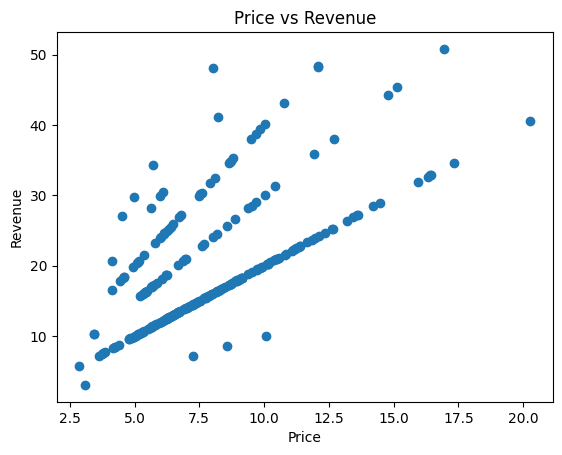

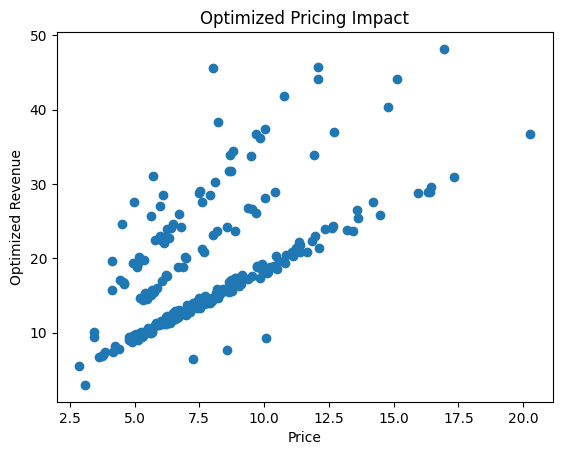

In [14]:
# VISUALIZATION

plt.scatter(df['price'], df['revenue'])
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title("Price vs Revenue")
plt.show()

plt.scatter(df['price'], df['optimized_revenue'])
plt.xlabel("Price")
plt.ylabel("Optimized Revenue")
plt.title("Optimized Pricing Impact")
plt.show()


In [15]:
# SAVE OUTPUT
customer_df.to_csv("customer_segments.csv", index=False)
df.to_csv("pricing_analysis.csv", index=False)